#  XGBoost  Training(2016—2019) - Respira SP

Este notebook dá continuidade à preparação dos dados, utilizando os datasets supervisionados da base **2016–2019** para treinar, regularizar e avaliar modelos XGBoost na previsão de `PM2.5` 24 horas à frente.

Foram comparadas três estratégias de pré-processamento para tratamento de gaps, além de diferentes configurações do XGBoost: modelo inicial, modelo regularizado, modelo com novas features temporais e modelo regularizado com novas features temporais.

## O que foi feito

* Carregamento dos datasets supervisionados referentes às três estratégias de pré-processamento;
* Adição das features meteorológicas ausentes a partir da base Open-Meteo:

  * `precipitation`
  * `wind_speed_10m`
* Remoção da coluna `MP2.5` original para evitar seu uso direto como feature no modelo;
* Definição das features utilizadas no treinamento e do target `target_24h`;
* Realização do split temporal dos dados:

  * Treino: dados anteriores a 2018;
  * Validação: dados de 2018;
  * Teste: dados de 2019;
* Treinamento de um baseline simples baseado em `PM2.5_lag_24h`;
* Treinamento inicial do modelo XGBoost para cada estratégia de pré-processamento;
* Avaliação dos modelos com `MAE`, `RMSE` e `R²`;
* Comparação entre baseline e XGBoost no conjunto de validação;
* Avaliação final dos modelos no conjunto de teste;
* Análise de `feature importance`;
* Análise de desempenho por split;
* Construção de learning curves para investigar possíveis sinais de overfitting, underfitting ou data leakage;
* Realização de `GridSearchCV` com `TimeSeriesSplit` para buscar configurações mais regularizadas;
* Treinamento de modelos XGBoost regularizados usando os melhores hiperparâmetros encontrados;
* Criação de novas features temporais:

  * `hora_sin` / `hora_cos`;
  * `mes_sin` / `mes_cos`;
  * `dia_semana_sin` / `dia_semana_cos`;
  * `PM2.5_diff_1h`;
  * `PM2.5_diff_3h`;
  * `PM2.5_diff_6h`;
  * `PM2.5_diff_24h`;
* Treinamento de XGBoost inicial com as novas features temporais;
* Treinamento de XGBoost regularizado com as novas features temporais;
* Novo GridSearch com as features temporais para verificar se os hiperparâmetros poderiam melhorar ainda mais o desempenho;
* Comparação final entre:

  * Modelos iniciais;
  * Modelos regularizados;
  * Modelos iniciais com features temporais;
  * Modelos regularizados com features temporais;
  * Modelos com GridSearch usando features temporais.

## Melhor configuração encontrada

A melhor configuração geral foi:

**Base:** 2016–2019
**Estratégia:** Estratégia 3 — interpolação de gaps pequenos + imputação por média sazonal
**Modelo:** XGBoost regularizado + features temporais

### Resultado em validação

* `MAE`: 7.519
* `RMSE`: 10.607
* `R²`: 0.300

### Resultado em teste

* `MAE`: 7.771
* `RMSE`: 10.787
* `R²`: 0.295

Embora a Estratégia 1 regularizada com features temporais tenha apresentado RMSE ligeiramente menor no teste, a Estratégia 3 regularizada com features temporais foi considerada a melhor configuração geral por apresentar melhor desempenho na validação, melhor `MAE` e melhor `R²` no teste, além de utilizar a estratégia mais completa de tratamento de gaps.

## Observação

Na base 2016–2019, a regularização do XGBoost reduziu sinais de overfitting observados nas learning curves iniciais e trouxe melhora consistente nas métricas de teste. A adição de novas features temporais também contribuiu para melhorar o desempenho, especialmente quando combinada com o modelo regularizado.

O novo GridSearch realizado com as features temporais não superou a configuração regularizada anterior com features temporais. Portanto, a melhor configuração final permaneceu sendo a Estratégia 3 com XGBoost regularizado e features temporais.

A base utilizada corresponde ao período histórico de **2016 a 2019** e mantém as seguintes features meteorológicas:

* `temperature_2m`
* `relative_humidity_2m`
* `precipitation`
* `wind_speed_10m`


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Importando as bases de dados 2016-2019
# Estrategia 1 sem imterpolação temporal / sazonal
df_estrategia01 = pd.read_csv("../data/data_sem_interpolacao/dados_pm25_umi_temp_2016_2019_nan.csv")
df_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


In [4]:
# Estrategia 2 sem imterpolação temporal / sazonal
df_estrategia02 = pd.read_csv("../data/data_interpolacao_gaps_menores/dados_pm25_umi_temp_2016_2019_interp12h.csv")
df_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


In [5]:
# Estrategia 2 sem imterpolação temporal / sazonal
df_estrategia03 = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_pm25_umi_temp_2016_2019_fill_mean.csv")
df_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,mes,hora,dia_semana,MP2.5_imputado_media
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,3,0,1,0
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,3,1,1,0
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,3,2,1,0
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,3,3,1,0
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,3,4,1,0


In [6]:
#Puxando o dataset openmeteo para adicionar todas as features atmosfericas
df_openmeteo = pd.read_csv("../data/openmeteo_historico_2013_2019.csv")
df_openmeteo.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2012-12-31 22:00:00-02:00,22.651001,89.586006,0.0,3.976330
1,2012-12-31 23:00:00-02:00,22.201000,90.384930,0.0,6.489992
2,2013-01-01 00:00:00-02:00,21.801000,90.357220,0.0,8.404284
3,2013-01-01 01:00:00-02:00,21.451000,90.053210,0.0,8.759178
4,2013-01-01 02:00:00-02:00,21.351000,88.658140,0.0,8.654986


In [7]:
if "date" in df_openmeteo.columns:
    df_openmeteo = df_openmeteo.rename(columns={"date": "time"})

In [8]:
df_openmeteo["time"] = pd.to_datetime(df_openmeteo["time"], utc=True)

df_estrategia01["time"] = pd.to_datetime(df_estrategia01["time"], utc=True)
df_estrategia02["time"] = pd.to_datetime(df_estrategia02["time"], utc=True)
df_estrategia03["time"] = pd.to_datetime(df_estrategia03["time"], utc=True)

In [9]:
features_openmeteo = [
    "time",
    "precipitation",
    "wind_speed_10m"
]

df_openmeteo_features = df_openmeteo[features_openmeteo].copy()

In [10]:
df_estrategia01 = df_estrategia01.merge(
    df_openmeteo_features,
    on="time",
    how="left"
)

df_estrategia02 = df_estrategia02.merge(
    df_openmeteo_features,
    on="time",
    how="left"
)

df_estrategia03 = df_estrategia03.merge(
    df_openmeteo_features,
    on="time",
    how="left"
)

In [11]:
print(df_estrategia01.shape)
print(df_estrategia02.shape)
print(df_estrategia03.shape)

df_estrategia01.head()

(30363, 6)
(30363, 6)
(30363, 10)


,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [12]:
print(df_estrategia01[["precipitation", "wind_speed_10m"]].isna().sum())
print(df_estrategia02[["precipitation", "wind_speed_10m"]].isna().sum())
print(df_estrategia03[["precipitation", "wind_speed_10m"]].isna().sum())

precipitation     0
wind_speed_10m    0
dtype: int64
precipitation     0
wind_speed_10m    0
dtype: int64
precipitation     0
wind_speed_10m    0
dtype: int64


## Preparando o dataset para o XGBoost

In [13]:
features_modelo = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "mes",
    "hora",
    "dia_semana",
    "PM2.5_lag_1h",
    "PM2.5_lag_3h",
    "PM2.5_lag_6h",
    "PM2.5_lag_12h",
    "PM2.5_lag_24h",
    "PM2.5_rolling_mean_3h",
    "PM2.5_rolling_mean_6h",
    "PM2.5_rolling_mean_12h",
    "PM2.5_rolling_mean_24h",
    "PM2.5_rolling_std_24h"
]

target = "target_24h"

In [14]:
def prep_df_xgb_2016_2019(df):
    df = df.copy()

    # Garantir ordenação temporal
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values("time").reset_index(drop=True)

    # Criar features temporais se ainda não existirem
    df["mes"] = df["time"].dt.month
    df["hora"] = df["time"].dt.hour
    df["dia_semana"] = df["time"].dt.dayofweek

    # Criar target 24h à frente
    df["target_24h"] = df["MP2.5"].shift(-24)

    # Criar lags de PM2.5
    lags = [1, 3, 6, 12, 24]

    for lag in lags:
        df[f"PM2.5_lag_{lag}h"] = df["MP2.5"].shift(lag)

    # Criar rolling features usando apenas passado
    rolling_windows = [3, 6, 12, 24]

    for window in rolling_windows:
        df[f"PM2.5_rolling_mean_{window}h"] = (
            df["MP2.5"]
            .shift(1)
            .rolling(window=window)
            .mean()
        )

    df["PM2.5_rolling_std_24h"] = (
        df["MP2.5"]
        .shift(1)
        .rolling(window=24)
        .std()
    )

    # Remover NaNs apenas nas features e target usados no modelo
    df_model = df.dropna(
        subset=features_modelo + [target]
    ).copy()

    return df_model

In [15]:
df_xgb_2016_estrategia01 = prep_df_xgb_2016_2019(df_estrategia01)
df_xgb_2016_estrategia02 = prep_df_xgb_2016_2019(df_estrategia02)
df_xgb_2016_estrategia03 = prep_df_xgb_2016_2019(df_estrategia03)

In [16]:
print(df_estrategia01.shape, df_xgb_2016_estrategia01.shape)
print(df_estrategia02.shape, df_xgb_2016_estrategia02.shape)
print(df_estrategia03.shape, df_xgb_2016_estrategia03.shape)

(30363, 6) (27017, 20)
(30363, 6) (28017, 20)
(30363, 10) (30315, 21)


In [17]:
print(df_xgb_2016_estrategia01[features_modelo + [target]].isna().sum().sum())
print(df_xgb_2016_estrategia02[features_modelo + [target]].isna().sum().sum())
print(df_xgb_2016_estrategia03[features_modelo + [target]].isna().sum().sum())

0
0
0


In [21]:
#Salvando os dfs
df_xgb_2016_estrategia01.to_csv(
    "../data/processed_data/xgb_estrategia01_2016_2019_target_24h.csv",
    index=False
)

df_xgb_2016_estrategia02.to_csv(
    "../data/processed_data/xgb_estrategia02_2016_2019_target_24h.csv",
    index=False
)

df_xgb_2016_estrategia03.to_csv(
    "../data/processed_data/xgb_estrategia03_2016_2019_target_24h.csv",
    index=False
)

## Fazer split temporal

In [18]:
#função para split temporal
def split_temporal(df, features, target):
    df = df.sort_values("time").copy()

    train = df[df["time"] < "2018-01-01"].copy()
    val = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].copy()
    test = df[df["time"] >= "2019-01-01"].copy()

    X_train = train[features]
    y_train = train[target]

    X_val = val[features]
    y_val = val[target]

    X_test = test[features]
    y_test = test[target]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [20]:
#split na 1 estrategia
X_train_01, X_val_01, X_test_01, y_train_01, y_val_01, y_test_01 = split_temporal(
    df_xgb_2016_estrategia01, features_modelo, target
)

#split na 2 estrategia
X_train_02, X_val_02, X_test_02, y_train_02, y_val_02, y_test_02 = split_temporal(
    df_xgb_2016_estrategia02, features_modelo, target
)

#split na 3 estrategia
X_train_03, X_val_03, X_test_03, y_train_03, y_val_03, y_test_03 = split_temporal(
    df_xgb_2016_estrategia03, features_modelo, target
)

In [21]:
print(X_train_01.shape, X_val_01.shape, X_test_01.shape)
print(X_train_02.shape, X_val_02.shape, X_test_02.shape)
print(X_train_03.shape, X_val_03.shape, X_test_03.shape)

(14532, 17) (7475, 17) (5010, 17)
(15192, 17) (7604, 17) (5221, 17)
(16080, 17) (8760, 17) (5475, 17)


In [23]:
print(X_train_01.isna().sum().sum(), X_val_01.isna().sum().sum(), X_test_01.isna().sum().sum())
print(X_train_02.isna().sum().sum(), X_val_02.isna().sum().sum(), X_test_02.isna().sum().sum())
print(X_train_03.isna().sum().sum(), X_val_03.isna().sum().sum(), X_test_03.isna().sum().sum())

0 0 0
0 0 0
0 0 0


In [24]:
print(y_train_01.isna().sum(), y_val_01.isna().sum(), y_test_01.isna().sum())
print(y_train_02.isna().sum(), y_val_02.isna().sum(), y_test_02.isna().sum())
print(y_train_03.isna().sum(), y_val_03.isna().sum(), y_test_03.isna().sum())

0 0 0
0 0 0
0 0 0


## Avaliação Baseline na validação

In [26]:
def avaliar_modelo(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [27]:
y_pred_baseline_01 = X_val_01["PM2.5_lag_24h"]
y_pred_baseline_02 = X_val_02["PM2.5_lag_24h"]
y_pred_baseline_03 = X_val_03["PM2.5_lag_24h"]

baseline_01 = avaliar_modelo(y_val_01, y_pred_baseline_01)
baseline_02 = avaliar_modelo(y_val_02, y_pred_baseline_02)
baseline_03 = avaliar_modelo(y_val_03, y_pred_baseline_03)

baseline_01, baseline_02, baseline_03

({'MAE': 11.016989966555183,
  'RMSE': 15.610750090711491,
  'R2': -0.39173078414061124},
 {'MAE': 11.028581448360514,
  'RMSE': 15.646441218400593,
  'R2': -0.411274593292444},
 {'MAE': 10.533703685044673,
  'RMSE': 15.031295586061354,
  'R2': -0.4053794239429711})

## Pipeline Modelo XGBoost

In [28]:
def train(X_train, y_train, X_val, y_val):
    pipeline = make_pipeline(
        XGBRegressor(
            objective="reg:squarederror",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_val)

    resultados = {
        "MAE": mean_absolute_error(y_val, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
        "R2": r2_score(y_val, y_pred)
    }

    return pipeline, y_pred, resultados

In [29]:
#Fazendo na estrategia 1
modelo_01, y_pred_val_01, resultados_xgb_01 = train(
    X_train_01, y_train_01, X_val_01, y_val_01
)

#Fazendo na estrategia 2
modelo_02, y_pred_val_02, resultados_xgb_02 = train(
    X_train_02, y_train_02, X_val_02, y_val_02
)

#Fazendo na estrategia 3
modelo_03, y_pred_val_03, resultados_xgb_03 = train(
    X_train_03, y_train_03, X_val_03, y_val_03
)

### Comparando baseline vs XGBoost

In [36]:
resultados_comparacao = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Baseline lag_24h(2016-2019)", **baseline_01},
    {"estrategia": "Estratégia 1", "modelo": "XGBoost(2016-2019)", **resultados_xgb_01},

    {"estrategia": "Estratégia 2", "modelo": "Baseline lag_24h(2016-2019)", **baseline_02},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost(2016-2019)", **resultados_xgb_02},

    {"estrategia": "Estratégia 3", "modelo": "Baseline lag_24h(2016-2019)", **baseline_03},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost(2016-2019)", **resultados_xgb_03},
])

resultados_comparacao

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Baseline lag_24h(2016-2019),11.016990,15.610750,-0.391731
1,Estratégia 1,XGBoost(2016-2019),8.137953,11.410769,0.256403
2,Estratégia 2,Baseline lag_24h(2016-2019),11.028581,15.646441,-0.411275
3,Estratégia 2,XGBoost(2016-2019),8.067963,11.275172,0.267130
4,Estratégia 3,Baseline lag_24h(2016-2019),10.533704,15.031296,-0.405379
5,Estratégia 3,XGBoost(2016-2019),7.691696,10.898750,0.261154


###  o XGBoost superou o baseline nas três estratégias de pré-processamento.

In [37]:
y_pred_test_01 = modelo_01.predict(X_test_01)
y_pred_test_02 = modelo_02.predict(X_test_02)
y_pred_test_03 = modelo_03.predict(X_test_03)

resultados_test_01 = avaliar_modelo(y_test_01, y_pred_test_01)
resultados_test_02 = avaliar_modelo(y_test_02, y_pred_test_02)
resultados_test_03 = avaliar_modelo(y_test_03, y_pred_test_03)

pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "XGBoost(2016-2019)", "split": "Teste", **resultados_test_01},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost(2016-2019)", "split": "Teste", **resultados_test_02},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost(2016-2019)", "split": "Teste", **resultados_test_03},
])

,estrategia,modelo,split,MAE,RMSE,R2
0,Estratégia 1,XGBoost(2016-2019),Teste,7.921754,10.997298,0.255137
1,Estratégia 2,XGBoost(2016-2019),Teste,7.935349,11.120742,0.257714
2,Estratégia 3,XGBoost(2016-2019),Teste,7.881494,10.916953,0.277773


###  A Estratégia 3 apresentou o melhor desempenho no conjunto de teste, com menor MAE, menor RMSE e maior R².

### Ver o feature importance do modelo

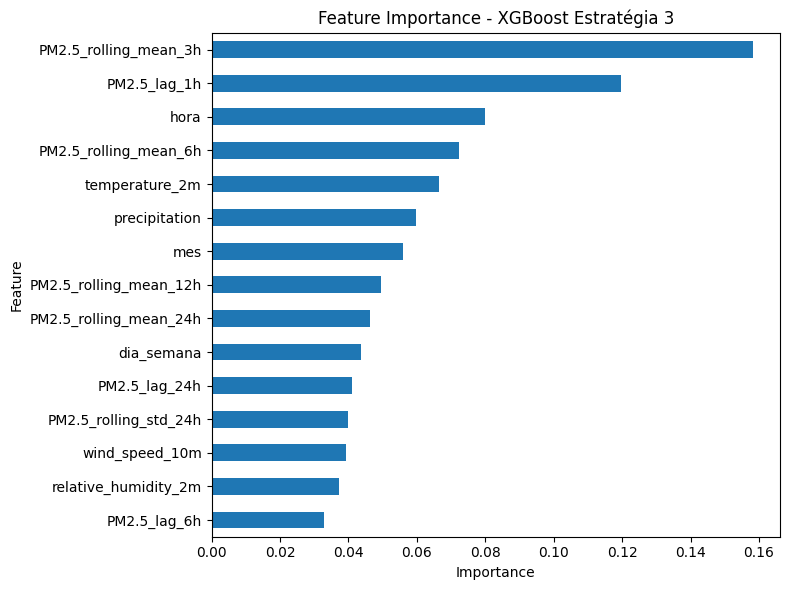

In [32]:
modelo_xgb_03 = modelo_03.named_steps["xgbregressor"]

feature_importance_03 = pd.DataFrame({
    "feature": X_train_03.columns,
    "importance": modelo_xgb_03.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_03.head(15).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost Estratégia 3")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### A análise de feature importance indica que o modelo utiliza principalmente informações recentes de PM2.5, como médias móveis e lags, além de variáveis temporais e meteorológicas.


## Learning curves do modelo nas estrategias

In [38]:
def plot_learning_curves_xgb_estrateg(
    estrategias,
    n_splits=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
):
    
    fig, axes = plt.subplots(
        nrows=len(estrategias),
        ncols=1,
        figsize=(10, 5 * len(estrategias)),
        sharex=False
    )

    if len(estrategias) == 1:
        axes = [axes]

    for ax, (nome, (X_train, y_train)) in zip(axes, estrategias.items()):

        pipeline_xgb = make_pipeline(
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=500,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
        )

        tscv = TimeSeriesSplit(n_splits=n_splits)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            estimator=pipeline_xgb,
            X=X_train,
            y=y_train,
            train_sizes=train_sizes,
            cv=tscv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

        train_rmse = -train_scores
        val_rmse = -val_scores

        train_rmse_mean = train_rmse.mean(axis=1)
        train_rmse_std = train_rmse.std(axis=1)

        val_rmse_mean = val_rmse.mean(axis=1)
        val_rmse_std = val_rmse.std(axis=1)

        ax.plot(
            train_sizes_abs,
            train_rmse_mean,
            marker="o",
            label="Train RMSE"
        )

        ax.plot(
            train_sizes_abs,
            val_rmse_mean,
            marker="o",
            label="Validation RMSE"
        )

        ax.fill_between(
            train_sizes_abs,
            train_rmse_mean - train_rmse_std,
            train_rmse_mean + train_rmse_std,
            alpha=0.2
        )

        ax.fill_between(
            train_sizes_abs,
            val_rmse_mean - val_rmse_std,
            val_rmse_mean + val_rmse_std,
            alpha=0.2
        )

        ax.set_title(f"Learning Curve - XGBoost {nome}")
        ax.set_xlabel("Tamanho do treino")
        ax.set_ylabel("RMSE")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

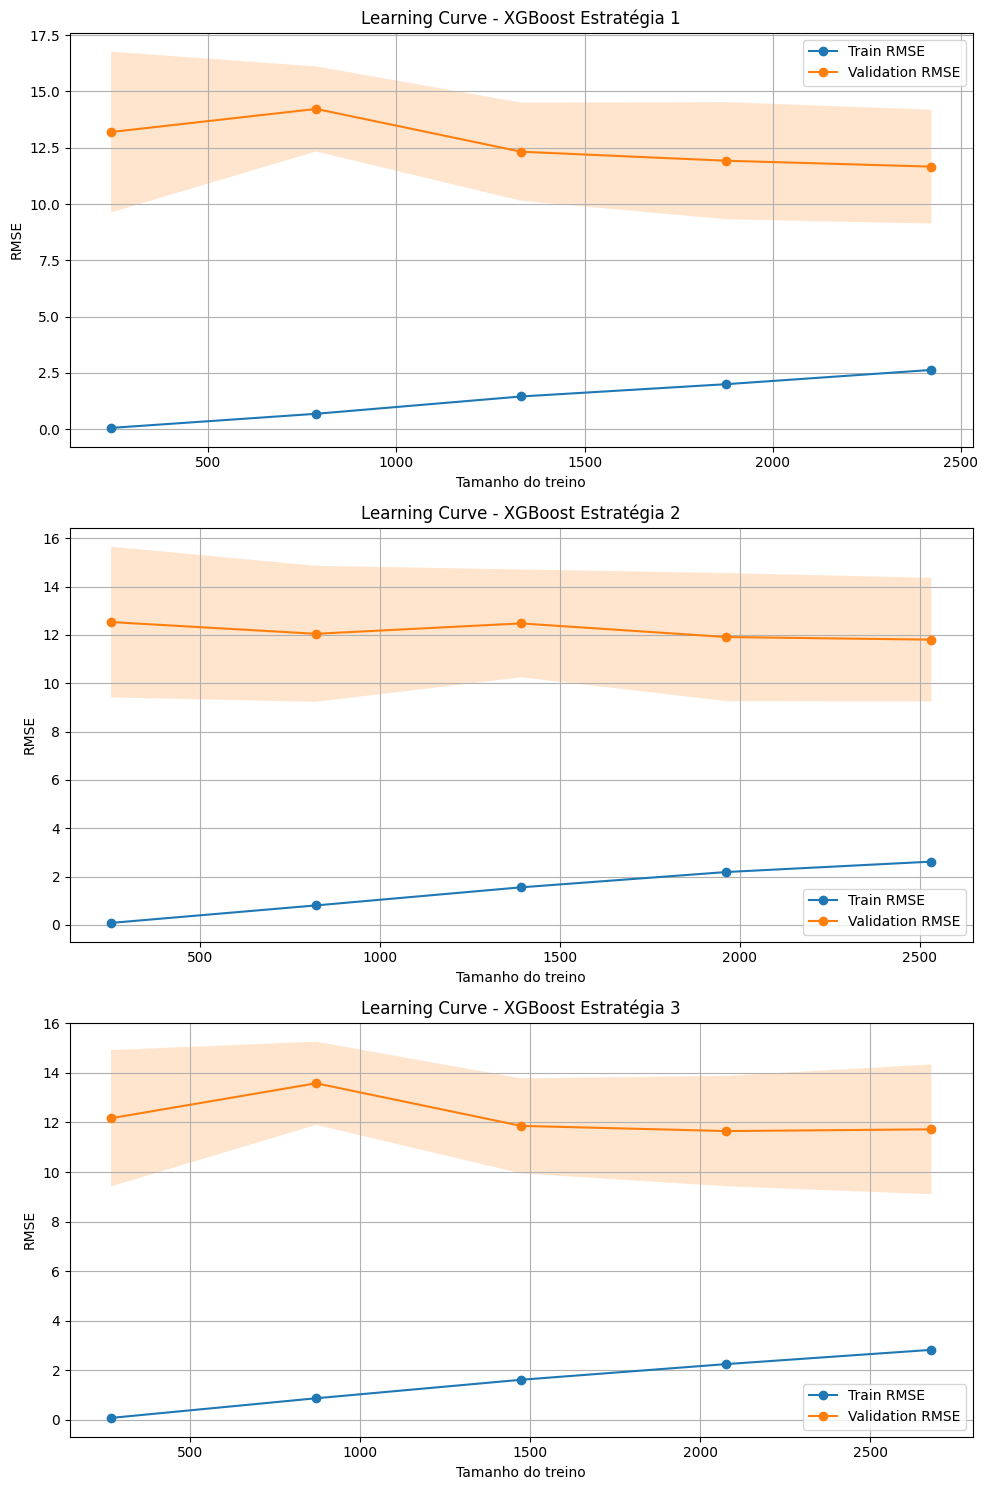

In [39]:
estrateg = {
    "Estratégia 1": (X_train_01, y_train_01),
    "Estratégia 2": (X_train_02, y_train_02),
    "Estratégia 3": (X_train_03, y_train_03),
}

plot_learning_curves_xgb_estrateg(estrateg)

### as learning curves indicam uma diferença relevante entre o erro de treino e o erro de validação, sugerindo tendência de overfitting. Esse comportamento pode estar relacionado à menor quantidade de dados disponível para treino em comparação com a base 2013–2019.

## Gridsearch com  hiperparâmetros diferentes e regularização

In [42]:
def grid_regularizar_xgb(X_train, y_train, X_val, y_val, nome_estrategia):
    xgb_base = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [300, 500, 800],
        "learning_rate": [0.01, 0.03, 0.05],
        "max_depth": [2, 3, 4],
        "min_child_weight": [3, 5, 7],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [1, 5, 10],
        "reg_alpha": [0, 0.1, 0.5]
    }

    tscv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_params = grid.best_params_

    modelo_final = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
        **best_params
    )

    modelo_final.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=0
    )

    y_pred_val = modelo_final.predict(X_val)

    resultados = avaliar_modelo(y_val, y_pred_val)

    print(nome_estrategia)
    print("Melhores parâmetros:", best_params)
    print("Melhor RMSE CV:", -grid.best_score_)
    print("Melhor iteração:", modelo_final.best_iteration)
    print("Resultados validação:", resultados)

    return grid, modelo_final, y_pred_val, resultados

In [43]:
grid_01, xgb_reg_01, y_pred_val_reg_01, resultados_reg_01 = grid_regularizar_xgb(
    X_train_01, y_train_01,
    X_val_01, y_val_01,
    "Estratégia 1"
)

Estratégia 1
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': 0.8}
Melhor RMSE CV: 10.729522509532197
Melhor iteração: 299
Resultados validação: {'MAE': 8.005778039147623, 'RMSE': 11.127834035733335, 'R2': 0.29282162666376854}


In [44]:
grid_02, xgb_reg_02, y_pred_val_reg_02, resultados_reg_02 = grid_regularizar_xgb(
    X_train_02, y_train_02,
    X_val_02, y_val_02,
    "Estratégia 2"
)

Estratégia 2
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.8}
Melhor RMSE CV: 10.842572757161463
Melhor iteração: 493
Resultados validação: {'MAE': 7.926579771137187, 'RMSE': 11.01475799711906, 'R2': 0.300592480834597}


In [45]:
grid_03, xgb_reg_03, y_pred_val_reg_03, resultados_reg_03 = grid_regularizar_xgb(
    X_train_03, y_train_03,
    X_val_03, y_val_03,
    "Estratégia 3"
)

Estratégia 3
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': 0.8}
Melhor RMSE CV: 10.592088712277903
Melhor iteração: 499
Resultados validação: {'MAE': 7.549256221341947, 'RMSE': 10.609834148561832, 'R2': 0.2998067001208047}


In [46]:
comparacao_reg = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Inicial", **resultados_xgb_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado", **resultados_reg_01},

    {"estrategia": "Estratégia 2", "modelo": "Inicial", **resultados_xgb_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado", **resultados_reg_02},

    {"estrategia": "Estratégia 3", "modelo": "Inicial", **resultados_xgb_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado", **resultados_reg_03},
])

comparacao_reg

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Inicial,8.137953,11.410769,0.256403
1,Estratégia 1,Regularizado,8.005778,11.127834,0.292822
2,Estratégia 2,Inicial,8.067963,11.275172,0.267130
3,Estratégia 2,Regularizado,7.926580,11.014758,0.300592
4,Estratégia 3,Inicial,7.691696,10.898750,0.261154
5,Estratégia 3,Regularizado,7.549256,10.609834,0.299807


### A regularização do modelo melhorou todas as estatisticas na validação

In [47]:
def plot_learning_curve_reg(X_train, y_train, best_params, titulo):
    modelo = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        **best_params
    )

    tscv = TimeSeriesSplit(n_splits=5)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=modelo,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    train_rmse = -train_scores
    val_rmse = -val_scores

    train_rmse_mean = train_rmse.mean(axis=1)
    train_rmse_std = train_rmse.std(axis=1)

    val_rmse_mean = val_rmse.mean(axis=1)
    val_rmse_std = val_rmse.std(axis=1)

    plt.figure(figsize=(10, 5))

    plt.plot(train_sizes, train_rmse_mean, marker="o", label="Train RMSE")
    plt.plot(train_sizes, val_rmse_mean, marker="o", label="Validation RMSE")

    plt.fill_between(
        train_sizes,
        train_rmse_mean - train_rmse_std,
        train_rmse_mean + train_rmse_std,
        alpha=0.2
    )

    plt.fill_between(
        train_sizes,
        val_rmse_mean - val_rmse_std,
        val_rmse_mean + val_rmse_std,
        alpha=0.2
    )

    plt.title(titulo)
    plt.xlabel("Tamanho do treino")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

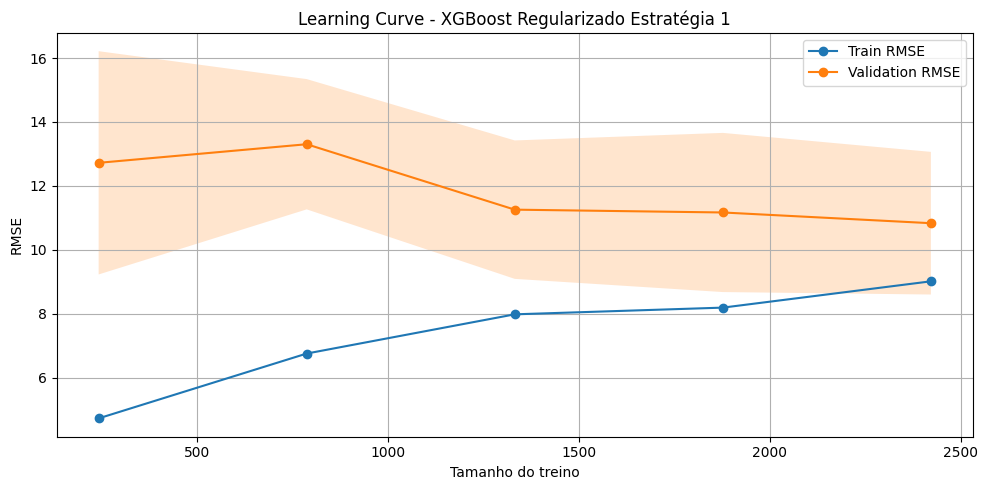

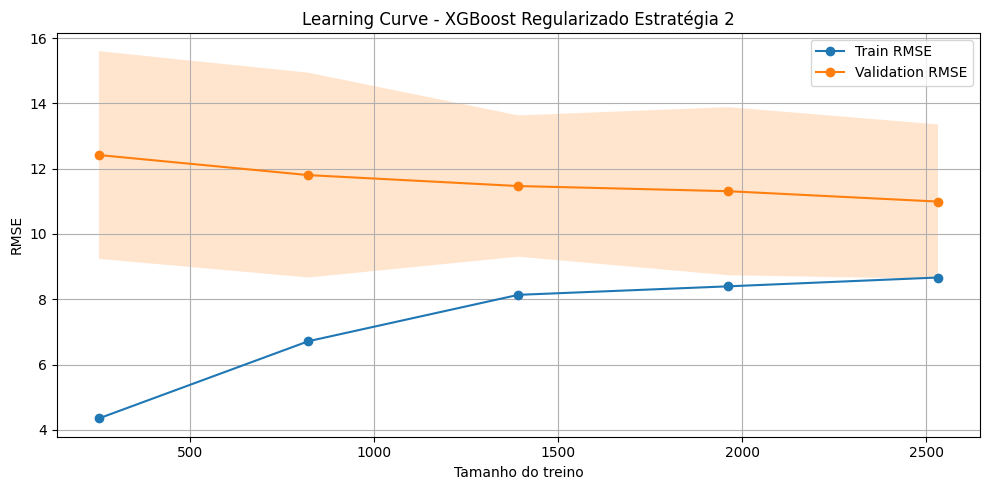

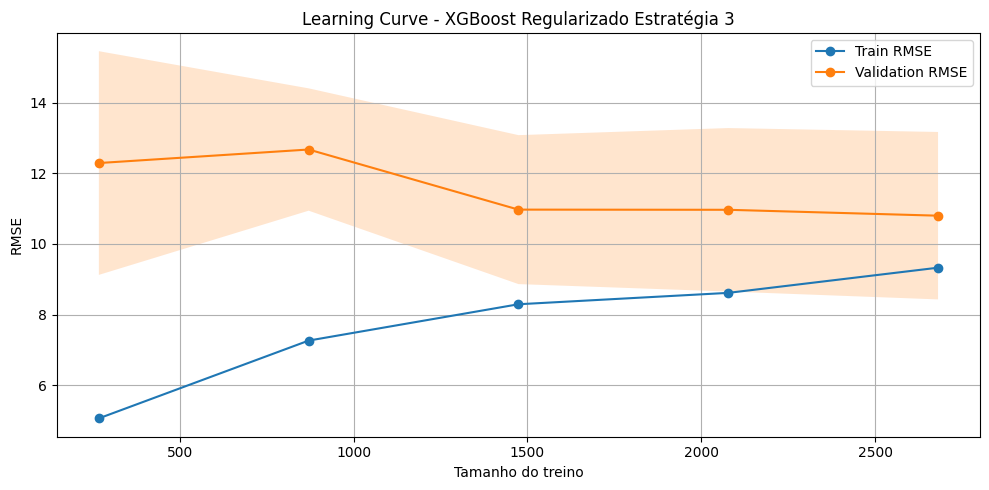

In [48]:
plot_learning_curve_reg(
    X_train_01,
    y_train_01,
    grid_01.best_params_,
    "Learning Curve - XGBoost Regularizado Estratégia 1"
)

plot_learning_curve_reg(
    X_train_02,
    y_train_02,
    grid_02.best_params_,
    "Learning Curve - XGBoost Regularizado Estratégia 2"
)

plot_learning_curve_reg(
    X_train_03,
    y_train_03,
    grid_03.best_params_,
    "Learning Curve - XGBoost Regularizado Estratégia 3"
)

### A regularização reduziu a tendência de overfitting observada nas learning curves iniciais. O erro de treino aumentou, enquanto o erro de validação diminuiu ou se aproximou do treino, indicando melhor capacidade de generalização.

In [50]:
y_pred_test_reg_03 = xgb_reg_03.predict(X_test_03)

resultados_test_reg_03 = avaliar_modelo(y_test_03, y_pred_test_reg_03)

y_pred_test_reg_02 = xgb_reg_02.predict(X_test_02)

resultados_test_reg_02 = avaliar_modelo(y_test_02, y_pred_test_reg_02)

y_pred_test_reg_01 = xgb_reg_01.predict(X_test_01)

resultados_test_reg_01 = avaliar_modelo(y_test_01, y_pred_test_reg_01)

In [51]:
comparacao_test_reg = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "XGBoost Regularizado", **resultados_test_reg_01},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost Regularizado", **resultados_test_reg_02},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost Regularizado", **resultados_test_reg_03},
])

comparacao_test_reg 

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,XGBoost Regularizado,7.861210,10.835420,0.276904
1,Estratégia 2,XGBoost Regularizado,7.867387,10.891308,0.288027
2,Estratégia 3,XGBoost Regularizado,7.816519,10.816802,0.290963


In [52]:
comparacao_test_models= pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "XGBoost Sem Regularização", **resultados_test_01},
    {"estrategia": "Estratégia 1", "modelo": "XGBoost Regularizado", **resultados_test_reg_01},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost Sem Regularização", **resultados_test_02},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost Regularizado", **resultados_test_reg_02},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost Sem Regularização", **resultados_test_03},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost Regularizado", **resultados_test_reg_03},
])

comparacao_test_models

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,XGBoost Sem Regularização,7.921754,10.997298,0.255137
1,Estratégia 1,XGBoost Regularizado,7.861210,10.835420,0.276904
2,Estratégia 2,XGBoost Sem Regularização,7.935349,11.120742,0.257714
3,Estratégia 2,XGBoost Regularizado,7.867387,10.891308,0.288027
4,Estratégia 3,XGBoost Sem Regularização,7.881494,10.916953,0.277773
5,Estratégia 3,XGBoost Regularizado,7.816519,10.816802,0.290963


### a regularização do XGBoost trouxe melhora consistente em todas as estratégias de pré-processamento. Em comparação com os modelos iniciais, os modelos regularizados apresentaram menor MAE, menor RMSE e maior R² no conjunto de teste.

### A melhor configuração foi a Estratégia 3 com XGBoost regularizado, que obteve MAE de 7.82, RMSE de 10.82 e R² de 0.29 no teste. Além disso, as learning curves indicaram redução da tendência de overfitting após a regularização.

## Adicionar feature engineering temporal

In [53]:
def add_feat_temp(X):
    X = X.copy()

    # Features cíclicas
    X["hora_sin"] = np.sin(2 * np.pi * X["hora"] / 24)
    X["hora_cos"] = np.cos(2 * np.pi * X["hora"] / 24)

    X["mes_sin"] = np.sin(2 * np.pi * X["mes"] / 12)
    X["mes_cos"] = np.cos(2 * np.pi * X["mes"] / 12)

    X["dia_semana_sin"] = np.sin(2 * np.pi * X["dia_semana"] / 7)
    X["dia_semana_cos"] = np.cos(2 * np.pi * X["dia_semana"] / 7)

    # Features de tendência do PM2.5
    X["PM2.5_diff_1h"] = X["PM2.5_lag_1h"] - X["PM2.5_lag_3h"]
    X["PM2.5_diff_3h"] = X["PM2.5_lag_3h"] - X["PM2.5_lag_6h"]
    X["PM2.5_diff_6h"] = X["PM2.5_lag_6h"] - X["PM2.5_lag_12h"]
    X["PM2.5_diff_24h"] = X["PM2.5_lag_1h"] - X["PM2.5_lag_24h"]

    return X

In [54]:
#Adicionando as features
X_train_01_fe = add_feat_temp(X_train_01)
X_val_01_fe = add_feat_temp(X_val_01)
X_test_01_fe = add_feat_temp(X_test_01)

X_train_02_fe = add_feat_temp(X_train_02)
X_val_02_fe = add_feat_temp(X_val_02)
X_test_02_fe = add_feat_temp(X_test_02)

X_train_03_fe = add_feat_temp(X_train_03)
X_val_03_fe = add_feat_temp(X_val_03)
X_test_03_fe = add_feat_temp(X_test_03)

In [55]:
#Conferir se não gerou nan
print(X_train_01_fe.isna().sum().sum(), X_val_01_fe.isna().sum().sum(), X_test_01_fe.isna().sum().sum())
print(X_train_02_fe.isna().sum().sum(), X_val_02_fe.isna().sum().sum(), X_test_02_fe.isna().sum().sum())
print(X_train_03_fe.isna().sum().sum(), X_val_03_fe.isna().sum().sum(), X_test_03_fe.isna().sum().sum())

0 0 0
0 0 0
0 0 0


In [56]:
def train_xgb_initial_fe(X_train, y_train, X_val, y_val):
    modelo = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="rmse"
    )

    modelo.fit(X_train, y_train)

    y_pred_val = modelo.predict(X_val)
    resultados = avaliar_modelo(y_val, y_pred_val)

    return modelo, y_pred_val, resultados

In [67]:
xgb_ini_fe_01, y_pred_val_ini_fe_01, resultados_ini_fe_01 = train_xgb_initial_fe(
    X_train_01_fe, y_train_01, X_val_01_fe, y_val_01
)

xgb_ini_fe_02, y_pred_val_ini_fe_02, resultados_ini_fe_02 = train_xgb_initial_fe(
    X_train_02_fe, y_train_02, X_val_02_fe, y_val_02
)

xgb_ini_fe_03, y_pred_val_ini_fe_03, resultados_ini_fe_03 = train_xgb_initial_fe(
    X_train_03_fe, y_train_03, X_val_03_fe, y_val_03
)

In [58]:
def train_xgb_reg_fe(X_train, y_train, X_val, y_val, best_params):
    modelo = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
        **best_params
    )

    modelo.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=0
    )

    y_pred_val = modelo.predict(X_val)
    resultados = avaliar_modelo(y_val, y_pred_val)

    return modelo, y_pred_val, resultados

In [68]:
xgb_reg_fe_01, y_pred_val_reg_fe_01, resultados_reg_fe_01 = train_xgb_reg_fe(
    X_train_01_fe, y_train_01,
    X_val_01_fe, y_val_01,
    grid_01.best_params_
)

xgb_reg_fe_02, y_pred_val_reg_fe_02, resultados_reg_fe_02 = train_xgb_reg_fe(
    X_train_02_fe, y_train_02,
    X_val_02_fe, y_val_02,
    grid_02.best_params_
)

xgb_reg_fe_03, y_pred_val_reg_fe_03, resultados_reg_fe_03 = train_xgb_reg_fe(
    X_train_03_fe, y_train_03,
    X_val_03_fe, y_val_03,
    grid_03.best_params_
)

In [61]:
# Comparar tudo na validação
comp_val_all = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Inicial", **resultados_xgb_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado", **resultados_reg_01},
    {"estrategia": "Estratégia 1", "modelo": "Inicial + Features Temporais", **resultados_ini_fe_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado + Features Temporais", **resultados_reg_fe_01},

    {"estrategia": "Estratégia 2", "modelo": "Inicial", **resultados_xgb_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado", **resultados_reg_02},
    {"estrategia": "Estratégia 2", "modelo": "Inicial + Features Temporais", **resultados_ini_fe_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado + Features Temporais", **resultados_reg_fe_02},

    {"estrategia": "Estratégia 3", "modelo": "Inicial", **resultados_xgb_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado", **resultados_reg_03},
    {"estrategia": "Estratégia 3", "modelo": "Inicial + Features Temporais", **resultados_ini_fe_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado + Features Temporais", **resultados_reg_fe_03},
])

comp_val_all.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
11,Estratégia 3,Regularizado + Features Temporais,7.519472,10.606534,0.300242
9,Estratégia 3,Regularizado,7.549256,10.609834,0.299807
8,Estratégia 3,Inicial,7.691696,10.898750,0.261154
10,Estratégia 3,Inicial + Features Temporais,7.682218,10.900085,0.260973
5,Estratégia 2,Regularizado,7.926580,11.014758,0.300592
7,Estratégia 2,Regularizado + Features Temporais,7.911825,11.042146,0.297110
3,Estratégia 1,Regularizado + Features Temporais,7.967998,11.106625,0.295515
1,Estratégia 1,Regularizado,8.005778,11.127834,0.292822
4,Estratégia 2,Inicial,8.067963,11.275172,0.267130
6,Estratégia 2,Inicial + Features Temporais,8.011876,11.314422,0.262019


In [62]:
print("Estratégia 1:", xgb_reg_fe_01.best_iteration, xgb_reg_fe_01.best_score)
print("Estratégia 2:", xgb_reg_fe_02.best_iteration, xgb_reg_fe_02.best_score)
print("Estratégia 3:", xgb_reg_fe_03.best_iteration, xgb_reg_fe_03.best_score)

Estratégia 1: 298 11.106625125710044
Estratégia 2: 499 11.042145560544862
Estratégia 3: 492 10.606533581403873


In [63]:
# Inicial + features temporais
y_pred_test_ini_fe_01 = xgb_ini_fe_01.predict(X_test_01_fe)
y_pred_test_ini_fe_02 = xgb_ini_fe_02.predict(X_test_02_fe)
y_pred_test_ini_fe_03 = xgb_ini_fe_03.predict(X_test_03_fe)

resultados_test_ini_fe_01 = avaliar_modelo(y_test_01, y_pred_test_ini_fe_01)
resultados_test_ini_fe_02 = avaliar_modelo(y_test_02, y_pred_test_ini_fe_02)
resultados_test_ini_fe_03 = avaliar_modelo(y_test_03, y_pred_test_ini_fe_03)

# Regularizado + features temporais
y_pred_test_reg_fe_01 = xgb_reg_fe_01.predict(X_test_01_fe)
y_pred_test_reg_fe_02 = xgb_reg_fe_02.predict(X_test_02_fe)
y_pred_test_reg_fe_03 = xgb_reg_fe_03.predict(X_test_03_fe)

resultados_test_reg_fe_01 = avaliar_modelo(y_test_01, y_pred_test_reg_fe_01)
resultados_test_reg_fe_02 = avaliar_modelo(y_test_02, y_pred_test_reg_fe_02)
resultados_test_reg_fe_03 = avaliar_modelo(y_test_03, y_pred_test_reg_fe_03)

In [64]:
comp_test_all = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Inicial", **resultados_test_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado", **resultados_test_reg_01},
    {"estrategia": "Estratégia 1", "modelo": "Inicial + Features Temporais", **resultados_test_ini_fe_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado + Features Temporais", **resultados_test_reg_fe_01},

    {"estrategia": "Estratégia 2", "modelo": "Inicial", **resultados_test_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado", **resultados_test_reg_02},
    {"estrategia": "Estratégia 2", "modelo": "Inicial + Features Temporais", **resultados_test_ini_fe_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado + Features Temporais", **resultados_test_reg_fe_02},

    {"estrategia": "Estratégia 3", "modelo": "Inicial", **resultados_test_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado", **resultados_test_reg_03},
    {"estrategia": "Estratégia 3", "modelo": "Inicial + Features Temporais", **resultados_test_ini_fe_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado + Features Temporais", **resultados_test_reg_fe_03},
])

comp_test_all.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
3,Estratégia 1,Regularizado + Features Temporais,7.800976,10.781961,0.284021
11,Estratégia 3,Regularizado + Features Temporais,7.770086,10.786682,0.294906
9,Estratégia 3,Regularizado,7.816519,10.816802,0.290963
1,Estratégia 1,Regularizado,7.861210,10.835420,0.276904
7,Estratégia 2,Regularizado + Features Temporais,7.820478,10.858209,0.292348
5,Estratégia 2,Regularizado,7.867387,10.891308,0.288027
10,Estratégia 3,Inicial + Features Temporais,7.868069,10.896476,0.280480
8,Estratégia 3,Inicial,7.881494,10.916953,0.277773
2,Estratégia 1,Inicial + Features Temporais,7.910999,10.963275,0.259739
0,Estratégia 1,Inicial,7.921754,10.997298,0.255137


### a combinação de regularização com novas features temporais apresentou os melhores resultados gerais. As features cíclicas (`hora_sin`, `hora_cos`, `mes_sin`, `mes_cos`, `dia_semana_sin`, `dia_semana_cos`) e as features de diferença entre lags de PM2.5 contribuíram para melhorar levemente a capacidade preditiva do modelo, especialmente quando combinadas com o XGBoost regularizado.


### A melhor configuração geral foi a Estratégia 3 com XGBoost regularizado e features temporais, que apresentou o maior R² no teste e desempenho muito próximo do melhor RMSE geral.

## Vou tentar fazer outro gridsearch agora com  as features temporais

In [69]:
grid_01_feat, xgb_reg_01_feat, y_pred_val_reg_01_feat, resultados_reg_01_feat = grid_regularizar_xgb(
    X_train_01_fe, y_train_01,
    X_val_01_fe, y_val_01,
    "Estratégia 1"
)

Estratégia 1
Melhores parâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 10, 'subsample': 1.0}
Melhor RMSE CV: 10.699783948094463
Melhor iteração: 498
Resultados validação: {'MAE': 8.082816916118098, 'RMSE': 11.218921833939437, 'R2': 0.2811969099030699}


In [72]:
grid_02_feat, xgb_reg_02_feat, y_pred_val_reg_02_feat, resultados_reg_02_feat = grid_regularizar_xgb(
    X_train_02_fe, y_train_02,
    X_val_02_fe, y_val_02,
    "Estratégia 2"
)

Estratégia 2
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}
Melhor RMSE CV: 10.768502928264727
Melhor iteração: 265
Resultados validação: {'MAE': 7.916764327314639, 'RMSE': 11.056828835224948, 'R2': 0.2952395072655347}


In [73]:
grid_03_feat, xgb_reg_03_feat, y_pred_val_reg_03_feat, resultados_reg_03_feat = grid_regularizar_xgb(
    X_train_03_fe, y_train_03,
    X_val_03_fe, y_val_03,
    "Estratégia 3"
)

Estratégia 3
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 800, 'reg_alpha': 0.5, 'reg_lambda': 10, 'subsample': 1.0}
Melhor RMSE CV: 10.523554296737888
Melhor iteração: 798
Resultados validação: {'MAE': 7.580942830885312, 'RMSE': 10.674571284670222, 'R2': 0.2912360105317857}


In [74]:
# Comparar tudo na validação
comp_val_all = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Inicial", **resultados_xgb_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado", **resultados_reg_01},
    {"estrategia": "Estratégia 1", "modelo": "Inicial + Features Temporais", **resultados_ini_fe_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado + Features Temporais", **resultados_reg_fe_01},
    {"estrategia": "Estratégia 1", "modelo": "Gridsearch + Features temporais", **resultados_reg_01_feat},

    {"estrategia": "Estratégia 2", "modelo": "Inicial", **resultados_xgb_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado", **resultados_reg_02},
    {"estrategia": "Estratégia 2", "modelo": "Inicial + Features Temporais", **resultados_ini_fe_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado + Features Temporais", **resultados_reg_fe_02},
    {"estrategia": "Estratégia 2", "modelo": "Gridsearch + Features temporais", **resultados_reg_02_feat},

    {"estrategia": "Estratégia 3", "modelo": "Inicial", **resultados_xgb_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado", **resultados_reg_03},
    {"estrategia": "Estratégia 3", "modelo": "Inicial + Features Temporais", **resultados_ini_fe_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado + Features Temporais", **resultados_reg_fe_03},
    {"estrategia": "Estratégia 3", "modelo": "Gridsearch + Features temporais", **resultados_reg_03_feat},
])

comp_val_all.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
13,Estratégia 3,Regularizado + Features Temporais,7.519472,10.606534,0.300242
11,Estratégia 3,Regularizado,7.549256,10.609834,0.299807
14,Estratégia 3,Gridsearch + Features temporais,7.580943,10.674571,0.291236
10,Estratégia 3,Inicial,7.691696,10.898750,0.261154
12,Estratégia 3,Inicial + Features Temporais,7.682218,10.900085,0.260973
6,Estratégia 2,Regularizado,7.926580,11.014758,0.300592
8,Estratégia 2,Regularizado + Features Temporais,7.911825,11.042146,0.297110
9,Estratégia 2,Gridsearch + Features temporais,7.916764,11.056829,0.295240
3,Estratégia 1,Regularizado + Features Temporais,7.967998,11.106625,0.295515
1,Estratégia 1,Regularizado,8.005778,11.127834,0.292822


In [75]:
# Gridsearch + Features temporais
y_pred_test_reg_feat_01 = xgb_reg_01_feat.predict(X_test_01_fe)
y_pred_test_reg_feat_02 = xgb_reg_02_feat.predict(X_test_02_fe)
y_pred_test_reg_feat_03 = xgb_reg_03_feat.predict(X_test_03_fe)

resultados_test_reg_feat_01 = avaliar_modelo(y_test_01, y_pred_test_reg_feat_01)
resultados_test_reg_feat_02 = avaliar_modelo(y_test_02, y_pred_test_reg_feat_02)
resultados_test_reg_feat_03 = avaliar_modelo(y_test_03, y_pred_test_reg_feat_03)

In [76]:
comp_test_all = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Inicial", **resultados_test_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado", **resultados_test_reg_01},
    {"estrategia": "Estratégia 1", "modelo": "Inicial + Features Temporais", **resultados_test_ini_fe_01},
    {"estrategia": "Estratégia 1", "modelo": "Regularizado + Features Temporais", **resultados_test_reg_fe_01},
    {"estrategia": "Estratégia 1", "modelo": "Gridsearch + Features temporais", **resultados_test_reg_feat_01},

    {"estrategia": "Estratégia 2", "modelo": "Inicial", **resultados_test_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado", **resultados_test_reg_02},
    {"estrategia": "Estratégia 2", "modelo": "Inicial + Features Temporais", **resultados_test_ini_fe_02},
    {"estrategia": "Estratégia 2", "modelo": "Regularizado + Features Temporais", **resultados_test_reg_fe_02},
    {"estrategia": "Estratégia 2", "modelo": "Gridsearch + Features temporais", **resultados_test_reg_feat_02},

    {"estrategia": "Estratégia 3", "modelo": "Inicial", **resultados_test_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado", **resultados_test_reg_03},
    {"estrategia": "Estratégia 3", "modelo": "Inicial + Features Temporais", **resultados_test_ini_fe_03},
    {"estrategia": "Estratégia 3", "modelo": "Regularizado + Features Temporais", **resultados_test_reg_fe_03},
    {"estrategia": "Estratégia 3", "modelo": "Gridsearch + Features temporais", **resultados_test_reg_feat_03},
])

comp_test_all.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
3,Estratégia 1,Regularizado + Features Temporais,7.800976,10.781961,0.284021
13,Estratégia 3,Regularizado + Features Temporais,7.770086,10.786682,0.294906
11,Estratégia 3,Regularizado,7.816519,10.816802,0.290963
1,Estratégia 1,Regularizado,7.861210,10.835420,0.276904
9,Estratégia 2,Gridsearch + Features temporais,7.781098,10.841553,0.294517
14,Estratégia 3,Gridsearch + Features temporais,7.802897,10.841724,0.287692
8,Estratégia 2,Regularizado + Features Temporais,7.820478,10.858209,0.292348
4,Estratégia 1,Gridsearch + Features temporais,7.880973,10.870977,0.272150
6,Estratégia 2,Regularizado,7.867387,10.891308,0.288027
12,Estratégia 3,Inicial + Features Temporais,7.868069,10.896476,0.280480


## Conclusão

### A melhor configuração continua sendo: Estratégia 3 — XGBoost Regularizado + Features Temporais

In [77]:
comparacao_final = pd.DataFrame([
    # =========================
    # Base 2013-2019
    # =========================
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Inicial",
        "MAE": 7.843688,
        "RMSE": 10.826835,
        "R2": 0.278049
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Inicial + Features Temporais",
        "MAE": 7.821153,
        "RMSE": 10.830801,
        "R2": 0.277520
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Regularizado + Features Temporais",
        "MAE": 7.911754,
        "RMSE": 10.839834,
        "R2": 0.276315
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Regularizado + Features Temporais",
        "MAE": 7.919675,
        "RMSE": 10.859678,
        "R2": 0.288436
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Inicial + Features Temporais",
        "MAE": 7.849791,
        "RMSE": 10.864480,
        "R2": 0.287807
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Regularizado",
        "MAE": 7.950550,
        "RMSE": 10.869112,
        "R2": 0.272400
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Inicial",
        "MAE": 7.888167,
        "RMSE": 10.881101,
        "R2": 0.285626
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Regularizado",
        "MAE": 7.949236,
        "RMSE": 10.892696,
        "R2": 0.284103
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Inicial + Features Temporais",
        "MAE": 7.901522,
        "RMSE": 10.944566,
        "R2": 0.281047
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Regularizado + Features Temporais",
        "MAE": 7.991348,
        "RMSE": 10.960100,
        "R2": 0.279004
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Inicial",
        "MAE": 7.924267,
        "RMSE": 10.965247,
        "R2": 0.278327
    },
    {
        "base": "2013-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Regularizado",
        "MAE": 8.013802,
        "RMSE": 10.979200,
        "R2": 0.276489
    },

    # =========================
    # Base 2016-2019
    # =========================
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Regularizado + Features Temporais",
        "MAE": 7.800976,
        "RMSE": 10.781961,
        "R2": 0.284021
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Regularizado + Features Temporais",
        "MAE": 7.770086,
        "RMSE": 10.786682,
        "R2": 0.294906
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Regularizado",
        "MAE": 7.816519,
        "RMSE": 10.816802,
        "R2": 0.290963
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Regularizado",
        "MAE": 7.861210,
        "RMSE": 10.835420,
        "R2": 0.276904
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 2",
        "modelo": "GridSearch + Features Temporais",
        "MAE": 7.781098,
        "RMSE": 10.841553,
        "R2": 0.294517
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 3",
        "modelo": "GridSearch + Features Temporais",
        "MAE": 7.802897,
        "RMSE": 10.841724,
        "R2": 0.287692
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Regularizado + Features Temporais",
        "MAE": 7.820478,
        "RMSE": 10.858209,
        "R2": 0.292348
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 1",
        "modelo": "GridSearch + Features Temporais",
        "MAE": 7.880973,
        "RMSE": 10.870977,
        "R2": 0.272150
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Regularizado",
        "MAE": 7.867387,
        "RMSE": 10.891308,
        "R2": 0.288027
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Inicial + Features Temporais",
        "MAE": 7.868069,
        "RMSE": 10.896476,
        "R2": 0.280480
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 3",
        "modelo": "Inicial",
        "MAE": 7.881494,
        "RMSE": 10.916953,
        "R2": 0.277773
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Inicial + Features Temporais",
        "MAE": 7.910999,
        "RMSE": 10.963275,
        "R2": 0.259739
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 1",
        "modelo": "Inicial",
        "MAE": 7.921754,
        "RMSE": 10.997298,
        "R2": 0.255137
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Inicial + Features Temporais",
        "MAE": 7.926627,
        "RMSE": 11.110592,
        "R2": 0.259069
    },
    {
        "base": "2016-2019",
        "estrategia": "Estratégia 2",
        "modelo": "Inicial",
        "MAE": 7.935349,
        "RMSE": 11.120742,
        "R2": 0.257714
    },
])

# Ordenar do melhor para o pior pelo RMSE
comparacao_final = (
    comparacao_final
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

# Criar ranking
comparacao_final.insert(0, "rank", comparacao_final.index + 1)

comparacao_final

,rank,base,estrategia,modelo,MAE,RMSE,R2
0,1,2016-2019,Estratégia 1,Regularizado + Features Temporais,7.800976,10.781961,0.284021
1,2,2016-2019,Estratégia 3,Regularizado + Features Temporais,7.770086,10.786682,0.294906
2,3,2016-2019,Estratégia 3,Regularizado,7.816519,10.816802,0.290963
3,4,2013-2019,Estratégia 1,Inicial,7.843688,10.826835,0.278049
4,5,2013-2019,Estratégia 1,Inicial + Features Temporais,7.821153,10.830801,0.277520
5,6,2016-2019,Estratégia 1,Regularizado,7.861210,10.835420,0.276904
6,7,2013-2019,Estratégia 1,Regularizado + Features Temporais,7.911754,10.839834,0.276315
7,8,2016-2019,Estratégia 2,GridSearch + Features Temporais,7.781098,10.841553,0.294517
8,9,2016-2019,Estratégia 3,GridSearch + Features Temporais,7.802897,10.841724,0.287692
9,10,2016-2019,Estratégia 2,Regularizado + Features Temporais,7.820478,10.858209,0.292348
